<a href="https://colab.research.google.com/github/nakyung55/FintechAI/blob/main/4_%EC%8B%A0%EC%9A%A9%ED%8F%89%EA%B0%80%EB%AA%A8%ED%98%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **신용평가모형**


Dataset : 신용점수 분류 (https://www.kaggle.com/datasets/parisrohan/credit-score-classification/data)


- 데이터는 100,000건이며, 총 28개의 컬럼으로 구성됨
- Credit_Score 컬럼이 예측을 해야하는 신용등급 분류 값임
- 모델의 성능 지표 : f1 score

In [17]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import lightgbm as lgb
import pickle
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split

google_path = 'https://drive.google.com/uc?id='
file_id = '1j0qGYojlW9cgRghZZUv4gWLBFjR8W8nG'
output_name = 'train.csv'
gdown.download(google_path+file_id, output_name)

Downloading...
From: https://drive.google.com/uc?id=1j0qGYojlW9cgRghZZUv4gWLBFjR8W8nG
To: /content/train.csv
100%|██████████| 31.1M/31.1M [00:00<00:00, 72.8MB/s]


'train.csv'

In [24]:
train = pd.read_csv('train.csv')

train.isnull().sum()
train = train.fillna(0)
target_drop_columns = ['Name']
train_drop = train.drop(columns=target_drop_columns)
train_drop.duplicated().sum()

train_drop['Occupation'].value_counts(), train_drop.Occupation.nunique()

# 직업 컬럼의 데이터에 '_______'를 최빈값으로 대체
mode_occ = train_drop.loc[train_drop['Occupation'] != '_______', 'Occupation'].mode()[0]
train_drop['Occupation'] = train_drop['Occupation'].replace('_______', mode_occ)

train_drop.groupby('Credit_Score')['Total_EMI_per_month'].mean().reset_index()
train_drop.pivot_table(index='Num_Credit_Card', columns='Credit_Score', values='Credit_Utilization_Ratio', aggfunc='max')
train_drop['Num_Credit_Card'].value_counts().head(10)
train_drop['Annual_Income']
train_drop['Annual_Income'] = train_drop['Annual_Income'].apply(lambda x: x.replace('_', ''))
train_drop['Annual_Income'] = train_drop['Annual_Income'].astype(float)
train_drop['Age'] = train_drop['Age'].apply(lambda x : str(x).replace('_', ''))
train_drop['Age'] = train_drop['Age'].astype(int)
train_drop['Num_of_Loan'] = train_drop['Num_of_Loan'].apply(lambda x : x.replace('_', ''))
train_drop['Num_of_Loan'] = train_drop['Num_of_Loan'].astype(int)
train_drop['Outstanding_Debt'] = train_drop['Outstanding_Debt'].apply(lambda x : x.replace('_', ''))
train_drop['Outstanding_Debt'] = train_drop['Outstanding_Debt'].astype(float)

for col in train_drop.columns:
    if train_drop[col].dtype == 'object':
        train_drop[col] = train_drop[col].str.replace('_', '')

train_drop.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,110.649700,1.764157e+05,3564.961339,17.091280,22.47443,72.466040,3.009960,21.068780,27.208880,1426.220376,32.285173,1403.118217
std,686.244717,1.429618e+06,3295.207286,117.404834,129.05741,466.422621,62.647879,14.860104,191.308723,1155.129026,5.116875,8306.041270
min,-500.000000,7.005930e+03,0.000000,-1.000000,0.00000,1.000000,-100.000000,-5.000000,0.000000,0.230000,20.000000,0.000000
25%,24.000000,1.945750e+04,1183.864167,3.000000,4.00000,8.000000,1.000000,10.000000,3.000000,566.072500,28.052567,30.306660
50%,33.000000,3.757861e+04,2623.714167,6.000000,5.00000,13.000000,3.000000,18.000000,5.000000,1166.155000,32.305784,69.249473
75%,42.000000,7.279092e+04,5371.525000,7.000000,7.00000,20.000000,5.000000,28.000000,9.000000,1945.962500,36.496663,161.224249
max,8698.000000,2.419806e+07,15204.633333,1798.000000,1499.00000,5797.000000,1496.000000,67.000000,2597.000000,4998.070000,50.000000,82331.000000


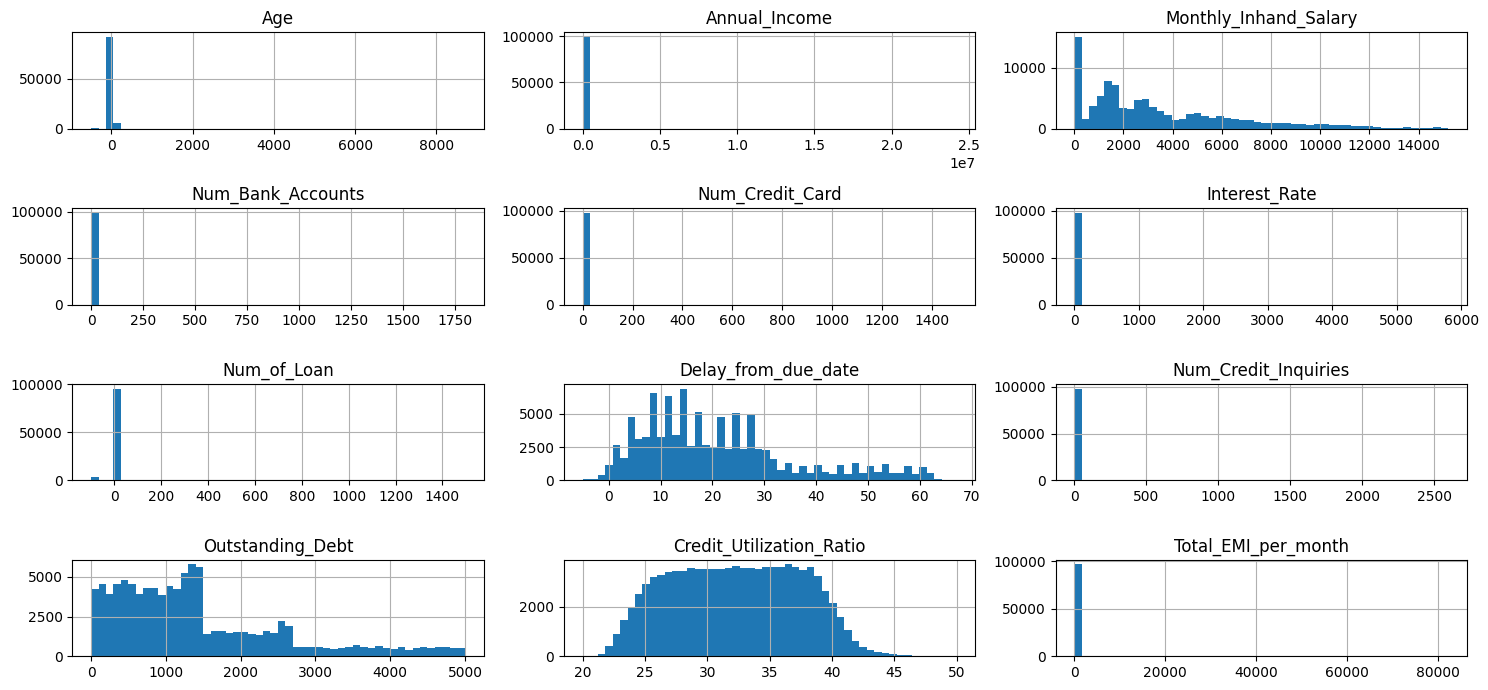

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Age                       100000 non-null  int64  
 4   SSN                       100000 non-null  object 
 5   Occupation                100000 non-null  object 
 6   Annual_Income             100000 non-null  float64
 7   Monthly_Inhand_Salary     100000 non-null  float64
 8   Num_Bank_Accounts         100000 non-null  int64  
 9   Num_Credit_Card           100000 non-null  int64  
 10  Interest_Rate             100000 non-null  int64  
 11  Num_of_Loan               100000 non-null  int64  
 12  Type_of_Loan              88592 non-null   object 
 13  Delay_from_due_date       100000 non-null  in

In [19]:
train_drop.hist(bins=50, figsize=(15, 7))
plt.tight_layout()
plt.show()

train_drop.info()

encoders = {}
for col in train_drop.columns:
    if train_drop[col].dtype == 'object':
        le = LabelEncoder()
        train_drop[col] = le.fit_transform(train_drop[col])
        encoders[col] = le

In [20]:
# 7:3으로 분리
train_data, valid_data = train_test_split(
    train_drop, test_size=0.3, random_state=42, stratify=train_drop['Credit_Score']
)

x_train = train_data.drop(columns=['Credit_Score'])
y_train = train_data['Credit_Score']
x_valid = valid_data.drop(columns=['Credit_Score'])
y_valid = valid_data['Credit_Score']
train_data.shape, valid_data.shape

((70000, 27), (30000, 27))

In [26]:
feature_names = train_data.columns[:-1]

def lgbm_microf1(truth, predictions):
    pred_labels = predictions.reshape(truth.shape[0], -1).argmax(axis=1)
    f1 = f1_score(truth, pred_labels, average='micro')
    return ('lgbm_microf1', f1, True)

params = {
    'n_estimators': 3000,
    'learning_rate': 0.02,
    'num_leaves': 80,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': 3,
}

model = lgb.LGBMClassifier(**params, random_state=42, verbosity=-1)
model.fit(
    x_train, y_train,
    eval_set=[(x_valid, y_valid)],
    eval_metric=lgbm_microf1,
    callbacks=[lgb.early_stopping(100)]
)

y_pred = model.predict(x_valid)
valid_data['pred'] = y_pred
valid_data

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2139]	valid_0's multi_logloss: 0.492965	valid_0's lgbm_microf1: 0.7967


,ID,Customer_ID,Month,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,pred
29191,89255,7695,1,17,7943,5,48356.660,4233.721667,3,4,...,1323.42,25.064197,101,2,45.441543,39903,4,61898,2,2
68811,29657,9136,0,32,9739,8,157814.320,13087.193333,4,5,...,411.89,29.694947,319,1,113.493214,65931,2,95109,0,2
78626,40084,10117,6,21,1526,5,147058.640,12319.886667,2,3,...,1377.33,39.337991,256,1,193.352961,54193,3,95250,0,0
30672,90736,4955,3,16,10024,13,72637.480,6064.123333,6,5,...,1933.90,33.915206,39,0,174.427356,22058,2,78696,1,1
81438,43071,7957,4,33,2214,7,12050.595,1159.216250,6,4,...,144.29,30.552478,274,1,7.167791,87303,5,36013,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77478,38864,10439,4,25,6190,1,24497.420,0.000000,4,3,...,946.84,28.382571,97,2,15.448183,78765,5,58810,2,2
1855,47903,2950,1,25,10765,11,142113.960,11903.830000,6,4,...,1037.68,30.667486,181,2,224.122139,1866,1,1444,2,2
88171,50227,5791,0,31,1178,7,83618.960,6744.246667,10,5,...,2624.85,28.153494,39,2,326.167190,44482,5,47729,1,1
23755,83819,6529,0,54,1785,13,155916.320,0.000000,6,6,...,551.80,25.787532,113,1,249.104133,8813,6,2748,2,2


f1 score =  0.7967


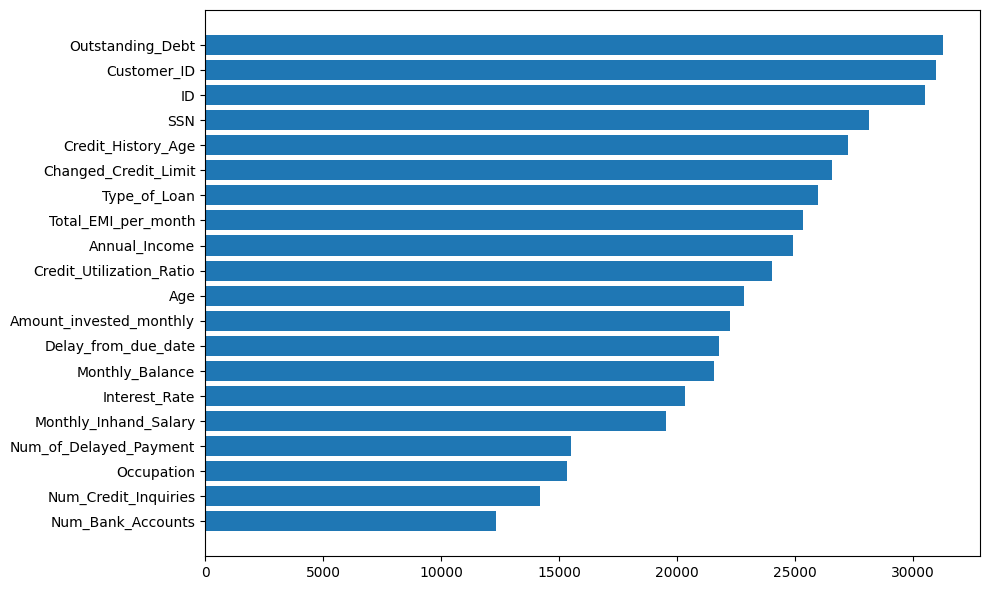

In [27]:
score = f1_score(y_valid, y_pred, average='micro')
print('f1 score = ', score)

val_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
})
val_imp = val_imp.sort_values(by='importance', ascending=False)
val_imp_top = val_imp.head(20)
plt.figure(figsize=(10,6))
plt.barh(val_imp_top['feature'], val_imp_top['importance'])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
save_object = [model, params, valid_data]
with open(file='my_model.pickle', mode='wb') as f:
    pickle.dump(save_object, f)
with open(file='my_model.pickle', mode='rb') as f:
    load_object = pickle.load(f)

model = load_object[0]
params = load_object[1]
valid_data = load_object[2]

valid_data['pred'] = model.predict(x_valid)
valid_data

,ID,Customer_ID,Month,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,pred
29191,89255,7695,1,17,7943,5,48356.660,4233.721667,3,4,...,1323.42,25.064197,101,2,45.441543,39903,4,61898,2,2
68811,29657,9136,0,32,9739,8,157814.320,13087.193333,4,5,...,411.89,29.694947,319,1,113.493214,65931,2,95109,0,2
78626,40084,10117,6,21,1526,5,147058.640,12319.886667,2,3,...,1377.33,39.337991,256,1,193.352961,54193,3,95250,0,0
30672,90736,4955,3,16,10024,13,72637.480,6064.123333,6,5,...,1933.90,33.915206,39,0,174.427356,22058,2,78696,1,1
81438,43071,7957,4,33,2214,7,12050.595,1159.216250,6,4,...,144.29,30.552478,274,1,7.167791,87303,5,36013,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77478,38864,10439,4,25,6190,1,24497.420,0.000000,4,3,...,946.84,28.382571,97,2,15.448183,78765,5,58810,2,2
1855,47903,2950,1,25,10765,11,142113.960,11903.830000,6,4,...,1037.68,30.667486,181,2,224.122139,1866,1,1444,2,2
88171,50227,5791,0,31,1178,7,83618.960,6744.246667,10,5,...,2624.85,28.153494,39,2,326.167190,44482,5,47729,1,1
23755,83819,6529,0,54,1785,13,155916.320,0.000000,6,6,...,551.80,25.787532,113,1,249.104133,8813,6,2748,2,2


In [ ]:
score = f1_score(valid_data['Credit_Score'], valid_data['pred'], average='micro')
print('f1 score = ', score)

# 개발 방향
- 데이터 전처리 : 결측치를 0으로 대체하되, Occupation 컬럼의 비정상 값 _______은 최빈값으로 대체, object 타입 컬럼의 _ 제거
- 컬럼별 LabelEncoder 개별 적용 및 저장
- 모델 학습 : train/valid 7:3 분리, 과적합 방지를 위해 early stopping 적용, 작은 학습률로 세밀한 학습, micro f1 사용(데이터 전체 예측 품질 평가에 적합)


# 결과 해석
- 100 라운드 동안 개선이 없어 2139에서 학습이 종료되었고, 이는 과적합 직전 지점에서 멈췄고 파라미터 세팅이 안정적이라는 의미임
- micro f1 = 0.7967로 전체 데이터의 약 80%를 올바르게 분류함